In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully")
print("Total rows:", X.shape[0])
print("Total columns:", X.shape[1])

Dataset loaded successfully
Total rows: 569
Total columns: 30


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=41
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data scaled successfully")


Data scaled successfully


In [5]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model trained successfully")
print("Accuracy:", accuracy)

Model trained successfully
Accuracy: 1.0


In [6]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix
[[40  0]
 [ 0 74]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        74

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



In [7]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Precision: 1.0
Recall: 1.0


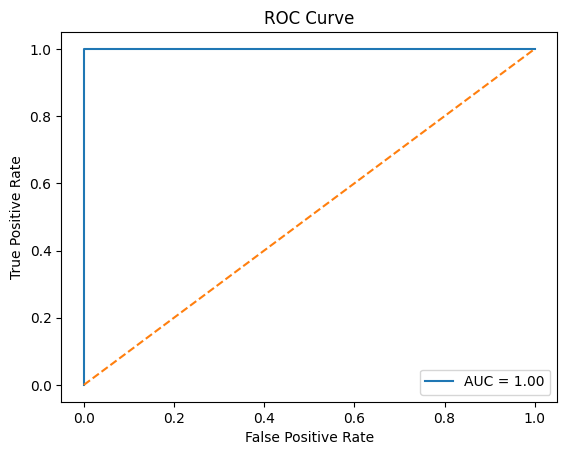

In [8]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [9]:
print("Coefficients:")
print(model.coef_)

print("\nIntercept:")
print(model.intercept_)

Coefficients:
[[-0.29465216 -0.34576561 -0.28268109 -0.35128304 -0.35705818  0.65233029
  -0.85372666 -0.95656483  0.1304847   0.31253154 -1.13327815  0.25987131
  -0.39435253 -1.0091577  -0.3099977   0.72998854  0.16993744 -0.236152
   0.3681369   0.52748593 -0.89453629 -1.17466268 -0.7078836  -0.87564794
  -0.4855493   0.05255043 -0.85133306 -0.85055793 -0.9928644  -0.55827651]]

Intercept:
[0.15444792]


In [10]:
import numpy as np

odds_ratio = np.exp(model.coef_)

print("Odds Ratio:")
print(odds_ratio)

Odds Ratio:
[[0.74479061 0.70767834 0.75376013 0.70378453 0.69973178 1.9200098
  0.42582507 0.38421045 1.13938051 1.36688105 0.32197604 1.29676319
  0.67411637 0.36452589 0.73344865 2.07505682 1.1852307  0.78966064
  1.44503986 1.69466644 0.40879712 0.30892317 0.49268582 0.416592
  0.61535909 1.05395571 0.42684554 0.42717653 0.37051387 0.57219439]]
